## Paddy Disease Classification with VGG16
This notebook demonstrates a transfer learning approach to classify rice paddy diseases using the VGG16 architecture with Weights & Biases integration for experiment tracking.

### Dataset Exploration

In [1]:
train_path = '/kaggle/input/paddy-doctor-disease/split/kaggle/working/paddy-doctor-disease/paddy-doctor-diseases-small_split_400/train'
test_path  = '/kaggle/input/paddy-doctor-disease/split/kaggle/working/paddy-doctor-disease/paddy-doctor-diseases-small_split_400/test'

# !du --inodes '/kaggle/input/paddy-doctor-disease/split/kaggle/working/paddy-doctor-disease/paddy-doctor-diseases-small_split_400/test'
# !du --inodes '/kaggle/input/paddy-doctor-disease/split/kaggle/working/paddy-doctor-disease/paddy-doctor-diseases-small_split_400/train'

import glob
from pathlib import Path

print('train images')
for filepath in glob.glob(train_path + '/*/'):
    files = glob.glob(filepath + '*')
    print(f"{len(files)} \t {Path(filepath).name}")

print('test images')
for filepath in glob.glob(test_path + '/*/'):
    files = glob.glob(filepath + '*')
    print(f"{len(files)} \t {Path(filepath).name}")

train images
320 	 tungro
320 	 yellow_stem_borer
320 	 hispa
320 	 downy_mildew
320 	 black_stem_borer
320 	 bacterial_leaf_streak
320 	 bacterial_leaf_blight
320 	 brown_spot
320 	 blast
320 	 leaf_roller
320 	 normal
320 	 bacterial_panicle_blight
320 	 white_stem_borer
test images
80 	 tungro
80 	 yellow_stem_borer
80 	 hispa
80 	 downy_mildew
80 	 black_stem_borer
80 	 bacterial_leaf_streak
80 	 bacterial_leaf_blight
80 	 brown_spot
80 	 blast
80 	 leaf_roller
80 	 normal
80 	 bacterial_panicle_blight
80 	 white_stem_borer


## Import Libraries and Set Configuration

This cell imports necessary libraries and sets up the configuration parameters for model training.

In [2]:
import numpy as np
import pandas as pd
import pickle
import cv2
import os
import glob
from os import listdir
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import BatchNormalization, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Activation, Flatten, Dropout, Dense
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import img_to_array
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import tensorflow.keras as keras

import keras
print(f"Keras version: {keras.__version__}")
from psutil import virtual_memory

SEED = 123
EPOCHS = 100
INIT_LR = 1e-3
BS = 32
default_image_size = tuple((256, 256))
image_size = 0
width = 256
height = 256
depth = 3

n_classes = len(glob.glob(train_path + '/*/'))
print(f"Number of classes: {n_classes}")

2025-04-21 12:49:22.468852: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745239762.694292      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745239762.760206      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Keras version: 3.5.0
Number of classes: 13


## Define VGG16 Transfer Learning Model Architecture

This function creates a VGG16-based model with transfer learning for disease classification. The pre-trained VGG16 architecture is used as a feature extractor with custom classification layers on top.

In [3]:
import os
from tensorflow.keras.models import Model
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from pathlib import Path
import numpy as np

def create_model(input_shape, n_classes, optimizer='rmsprop', fine_tune=0):
    """
    Compiles a model integrated with VGG16 pretrained layers
    
    input_shape: tuple - the shape of input images (width, height, channels)
    n_classes: int - number of classes for the output layer
    optimizer: string - instantiated optimizer to use for training. Defaults to 'RMSProp'
    fine_tune: int - The number of pre-trained layers to unfreeze.
                If set to 0, all pretrained layers will freeze during training
    """
    
    # Pretrained convolutional layers are loaded using the Imagenet weights.
    # Include_top is set to False, in order to exclude the model's fully-connected layers.
    conv_base = VGG16(include_top=False,
                     weights='imagenet', 
                     input_shape=input_shape)
    
    # Defines how many layers to freeze during training.
    # Layers in the convolutional base are switched from trainable to non-trainable
    # depending on the size of the fine-tuning parameter.
    if fine_tune > 0:
        for layer in conv_base.layers[:-fine_tune]:
            layer.trainable = False
    else:
        for layer in conv_base.layers:
            layer.trainable = False

    # Create a new 'top' of the model (i.e. fully-connected layers).
    # This is 'bootstrapping' a new top_model onto the pretrained layers.
    top_model = conv_base.output
    top_model = Flatten(name="flatten")(top_model)
    top_model = Dense(1024, activation='relu')(top_model)
    top_model = Dropout(0.2)(top_model)
    
    output_layer = Dense(n_classes, activation='softmax')(top_model)
    
    # Group the convolutional base and new fully-connected layers into a Model object.
    model = Model(inputs=conv_base.input, outputs=output_layer)

    # Compiles the model for training.
    model.compile(optimizer=optimizer, 
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model

## Define a Simple CNN Model (Alternative Approach)

This function creates a simple CNN model for comparison with the VGG16 transfer learning approach.
This model has fewer parameters but may be useful as a baseline.

In [4]:
def get_model():
    model = Sequential()
    inputShape = (height, width, depth)
    chanDim = -1
    print(K.image_data_format())
    if K.image_data_format() == "channels_first":
        inputShape = (depth, height, width)
        chanDim = 1
    model.add(Conv2D(32, (3, 3), padding="same",input_shape=inputShape))
    model.add(Activation("relu"))
    model.add(BatchNormalization(axis=chanDim))
    model.add(MaxPooling2D(pool_size=(3, 3)))
    model.add(Dropout(0.25))
    model.add(Conv2D(64, (3, 3), padding="same"))
    model.add(Activation("relu"))
    model.add(BatchNormalization(axis=chanDim))
    model.add(Conv2D(64, (3, 3), padding="same"))
    model.add(Activation("relu"))
    model.add(BatchNormalization(axis=chanDim))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))
    model.add(Conv2D(128, (3, 3), padding="same"))
    model.add(Activation("relu"))
    model.add(BatchNormalization(axis=chanDim))
    model.add(Conv2D(128, (3, 3), padding="same"))
    model.add(Activation("relu"))
    model.add(BatchNormalization(axis=chanDim))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))
    model.add(Flatten())
    model.add(Dense(1024))
    model.add(Activation("relu"))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(n_classes))
    model.add(Activation("softmax"))
    
    # Changed from lr to learning_rate (updated API)
    opt = Adam(learning_rate=INIT_LR)
    
    model.compile(loss="binary_crossentropy", optimizer=opt, metrics=["accuracy"])
    return model

model = get_model()
# Uncomment if needed:
# plot_model(model, '/kaggle/working/model.png', show_shapes=True)

channels_last


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1745239775.520505      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


## Initialize the VGG16 Model
#
We'll create our VGG16 transfer learning model with fine-tuning of the last 2 layers.
Fine-tuning allows the model to adapt pre-trained features to our specific task.

In [5]:
input_shape = (256, 256, 3)
# Use a smaller learning rate with the correct parameter name
optim_2 = Adam(learning_rate=0.0001)

# Re-compile the model, this time leaving the last 2 layers unfrozen for Fine-Tuning
vgg16_model = create_model(input_shape, n_classes, optim_2, fine_tune=2)
vgg16_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 256, 256, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 256, 256, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 128, 128, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 128, 128, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 128, 128, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 64, 64, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 64, 64, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 64, 64, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 64, 64, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 32, 32, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 32, 32, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 32, 32, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 32, 32, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 16, 16, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 8, 8, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1024)                │      33,555,456 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 48,283,469 (184.19 MB)

 Trainable params: 35,928,589 (137.06 MB)

 Non-trainable params: 12,354,880 (47.13 MB)

## Configure Data Generators

Set up data generators for training, validation, and testing with appropriate augmentation settings.
Data augmentation helps increase the diversity of training examples, which can improve model generalization.

In [6]:
image_datagen = ImageDataGenerator(featurewise_center=False,
                 samplewise_center=False,
                 featurewise_std_normalization=False,
                 samplewise_std_normalization=False,
                 zca_whitening=False,
                 rotation_range=5,
                 shear_range=0.2,
                 zoom_range=0.2,
                 width_shift_range=0.05,
                 height_shift_range=0.05,
                 channel_shift_range=0.,
                 fill_mode='nearest',
                 horizontal_flip=True,
                 vertical_flip=False,
                 rescale=1./255,
                 validation_split=0.2)

train_generator = image_datagen.flow_from_directory(    
    directory = train_path,
    subset='training',
    target_size=(256, 256),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=True,
    seed=SEED)

valid_generator = image_datagen.flow_from_directory(    
    directory=train_path,
    subset='validation',
    target_size=(256, 256),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=True,
    seed=SEED)

test_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(    
    directory=test_path,
    target_size=(256, 256),
    color_mode="rgb",
    batch_size=1,
    classes=['.'],
    class_mode=None,
    shuffle=False,
    seed=SEED)

print("Class indices mapping:")
print(train_generator.class_indices)
print(f"Total test samples: {test_generator.samples}")

Found 3328 images belonging to 13 classes.
Found 832 images belonging to 13 classes.
Found 1040 images belonging to 1 classes.
Class indices mapping:
{'bacterial_leaf_blight': 0, 'bacterial_leaf_streak': 1, 'bacterial_panicle_blight': 2, 'black_stem_borer': 3, 'blast': 4, 'brown_spot': 5, 'downy_mildew': 6, 'hispa': 7, 'leaf_roller': 8, 'normal': 9, 'tungro': 10, 'white_stem_borer': 11, 'yellow_stem_borer': 12}
Total test samples: 1040


## Set Up Callbacks for Model Training

We define callbacks to improve the training process:

1. **PlotLossesCallback**: Live visualization of training and validation loss
2. **ModelCheckpoint**: Save the best model during training
3. **EarlyStopping**: Stop training when validation metrics stop improving
4. **WandbCallback**: Log training metrics to Weights & Biases for experiment tracking

In [7]:
# Install livelossplot if needed
!pip install livelossplot

In [8]:
from livelossplot.inputs.keras import PlotLossesCallback
plot_loss_1 = PlotLossesCallback()

# ModelCheckpoint callback - updated to use .keras extension for newer TensorFlow versions
tl_checkpoint_1 = ModelCheckpoint(filepath='vgg_model_ft.weights.best.keras',
                                 save_best_only=True,
                                 verbose=1)

# EarlyStopping
early_stop = EarlyStopping(monitor='val_loss',
                          patience=10,
                          restore_best_weights=True,
                          mode='min')

## Configure Weights & Biases Integration

Weights & Biases (wandb) is a tool for tracking and visualizing machine learning experiments.
We'll set up wandb to log training metrics, model architecture, and hyperparameters.

In [9]:
import wandb
from tensorflow.keras.callbacks import Callback

# Login to wandb with your API key
wandb.login(key="f54d876ebca391d5a1ed3eebb7a43aa7bea9da21")

# Initialize a wandb run
run = wandb.init(
    project="project-ablations",
    name="vgg16-baseline",
    config={
        "epochs": EPOCHS,
        "batch_size": BS,
        "learning_rate": 0.0001,
        "fine_tune_layers": 2,
        "architecture": "VGG16 Transfer Learning"
    }
)

# Create a custom wandb callback that avoids the graph error
class CustomWandbCallback(Callback):
    def __init__(self, monitor='val_loss', mode='auto', save_model=False):
        super(CustomWandbCallback, self).__init__()
        self.monitor = monitor
        self.mode = mode
        self.save_model = save_model
        self.best = float('inf') if mode == 'min' else float('-inf')
        
    def on_epoch_end(self, epoch, logs=None):
        # Log metrics at the end of each epoch
        if logs:
            wandb.log(logs, step=epoch)
            
            # Save model if it's the best so far
            if self.save_model:
                current = logs.get(self.monitor)
                if current is not None:
                    if (self.mode == 'min' and current < self.best) or \
                       (self.mode == 'max' and current > self.best):
                        self.best = current
                        self.model.save(f'model-best-{self.monitor}-{current:.4f}.keras')
                        wandb.save(f'model-best-{self.monitor}-{current:.4f}.keras')

# Create the custom callback that will work with your TensorFlow version
wandb_callback = CustomWandbCallback(
    monitor="val_accuracy",
    mode="max",
    save_model=False
)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nigibril1 (nigibril1-gibril-tech) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


## Train the VGG16 Model

Now we'll train the VGG16 model with the configured generators and callbacks, including 
our wandb integration for experiment tracking.

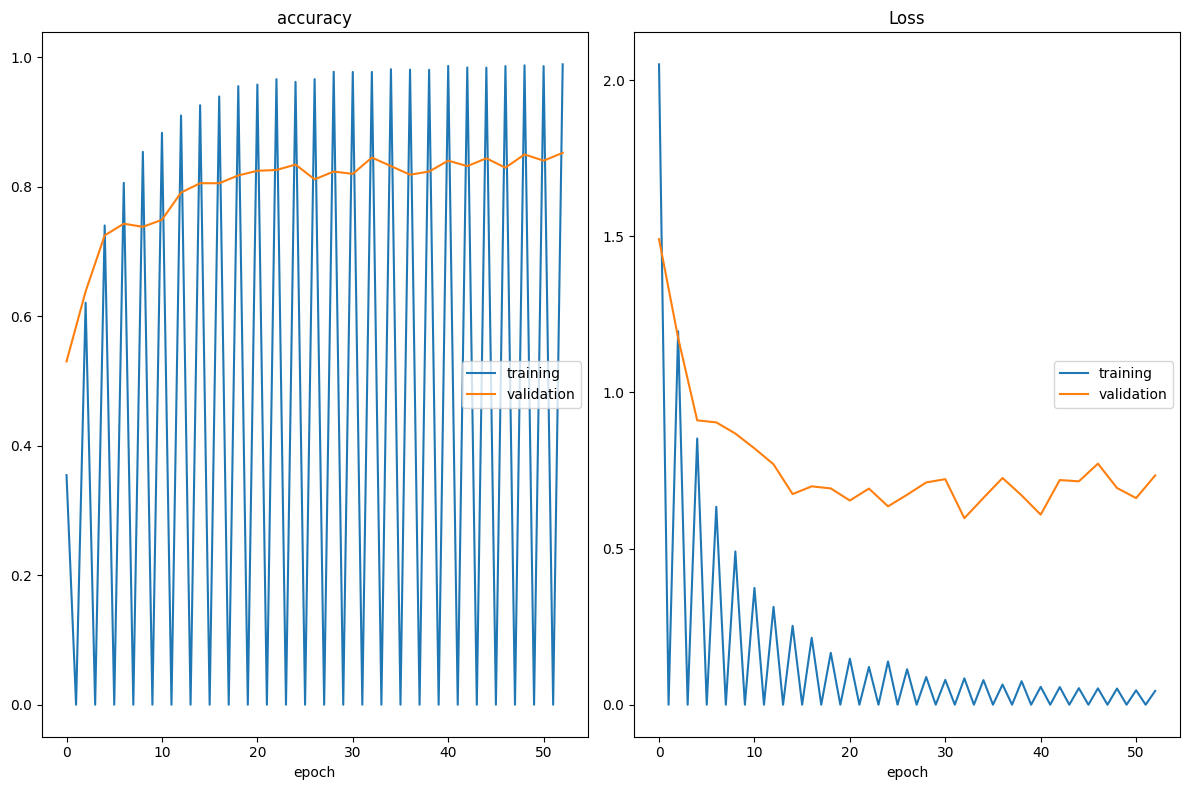

accuracy
	training         	 (min:    0.000, max:    0.989, cur:    0.989)
	validation       	 (min:    0.530, max:    0.852, cur:    0.852)
Loss
	training         	 (min:    0.000, max:    2.050, cur:    0.044)
	validation       	 (min:    0.597, max:    1.491, cur:    0.734)
104/104 ━━━━━━━━━━━━━━━━━━━━ 58s 533ms/step - accuracy: 0.9865 - loss: 0.0522 - val_accuracy: 0.8522 - val_loss: 0.7340
CPU times: user 50min 2s, sys: 39.8 s, total: 50min 42s
Wall time: 27min 17s


In [10]:
%%time
plot_loss_2 = PlotLossesCallback()
STEP_SIZE_TRAIN = train_generator.n//train_generator.batch_size
STEP_SIZE_VALID = valid_generator.n//valid_generator.batch_size

# Use fit instead of fit_generator (which is deprecated)
vgg16_history = vgg16_model.fit(
    train_generator,
    steps_per_epoch=STEP_SIZE_TRAIN,
    validation_data=valid_generator,
    validation_steps=STEP_SIZE_VALID,
    callbacks=[tl_checkpoint_1, early_stop, plot_loss_2, wandb_callback],
    verbose=1,
    epochs=EPOCHS
)

## Visualize Training History

Let's plot the training and validation metrics to understand how our model performed during training.

In [11]:
# Check if the input directory exists
!ls -l /kaggle/input

total 0
drwxr-xr-x 9 nobody nogroup 0 Apr 17 14:44 paddy-doctor-disease


In [12]:
# Verify test directory contents
test_path_new = '/kaggle/input/paddy-doctor-disease/split/kaggle/working/paddy-doctor-disease/paddy-doctor-diseases-small_split_400/test'

for filepath in glob.glob(test_path_new + '/*/'):
    files = glob.glob(filepath + '*')
    print(f"{len(files)} \t {Path(filepath).name}")

80 	 tungro
80 	 yellow_stem_borer
80 	 hispa
80 	 downy_mildew
80 	 black_stem_borer
80 	 bacterial_leaf_streak
80 	 bacterial_leaf_blight
80 	 brown_spot
80 	 blast
80 	 leaf_roller
80 	 normal
80 	 bacterial_panicle_blight
80 	 white_stem_borer


## Prepare Model for Prediction

We'll get the class names and prepare to run predictions on our test set.

In [13]:
class_subset = sorted(os.listdir(test_path_new)) # Get all class directories
print(f"Classes to predict: {class_subset}")

Classes to predict: ['bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight', 'black_stem_borer', 'blast', 'brown_spot', 'downy_mildew', 'hispa', 'leaf_roller', 'normal', 'tungro', 'white_stem_borer', 'yellow_stem_borer']


## Run Predictions on Test Data

We'll run our trained model on the test dataset to evaluate its performance.

In [14]:
test_generator_vgg = ImageDataGenerator(rescale=1./255).flow_from_directory(    
    directory=test_path_new,
    target_size=(256, 256),
    color_mode="rgb",
    batch_size=1,
    classes=class_subset,
    class_mode="categorical",  # Changed from None to categorical to get true class labels
    shuffle=False,
    seed=SEED)

# Load the best weights
vgg16_model.load_weights('vgg_model_ft.weights.best.keras')

# Get predictions
vgg_preds_ft = vgg16_model.predict(test_generator_vgg)
vgg_pred_classes_ft = np.argmax(vgg_preds_ft, axis=1)

Found 1040 images belonging to 13 classes.
1040/1040 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step


## Evaluate Model Performance

We'll calculate accuracy and generate a detailed classification report to understand 
how well our model performed across different disease classes.

In [15]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

class_names = test_generator_vgg.class_indices.keys()
true_classes = test_generator_vgg.classes

vgg_acc_ft = accuracy_score(true_classes, vgg_pred_classes_ft)
print("VGG16 Model Accuracy with Fine-Tuning: {:.2f}%".format(vgg_acc_ft * 100))

cls_report = classification_report(true_classes, vgg_pred_classes_ft, 
                                   target_names=class_names, digits=5)
print(cls_report)

VGG16 Model Accuracy with Fine-Tuning: 87.12%
                          precision    recall  f1-score   support

   bacterial_leaf_blight    0.86747   0.90000   0.88344        80
   bacterial_leaf_streak    0.98765   1.00000   0.99379        80
bacterial_panicle_blight    0.98684   0.93750   0.96154        80
        black_stem_borer    0.82418   0.93750   0.87719        80
                   blast    0.89231   0.72500   0.80000        80
              brown_spot    0.80000   0.85000   0.82424        80
            downy_mildew    0.75728   0.97500   0.85246        80
                   hispa    0.88525   0.67500   0.76596        80
             leaf_roller    0.90909   0.87500   0.89172        80
                  normal    0.86250   0.86250   0.86250        80
                  tungro    0.76087   0.87500   0.81395        80
        white_stem_borer    0.92537   0.77500   0.84354        80
       yellow_stem_borer    0.94937   0.93750   0.94340        80

                accuracy    

## Visualize Confusion Matrix

We'll create a heatmap visualization of the confusion matrix to understand model performance across classes.

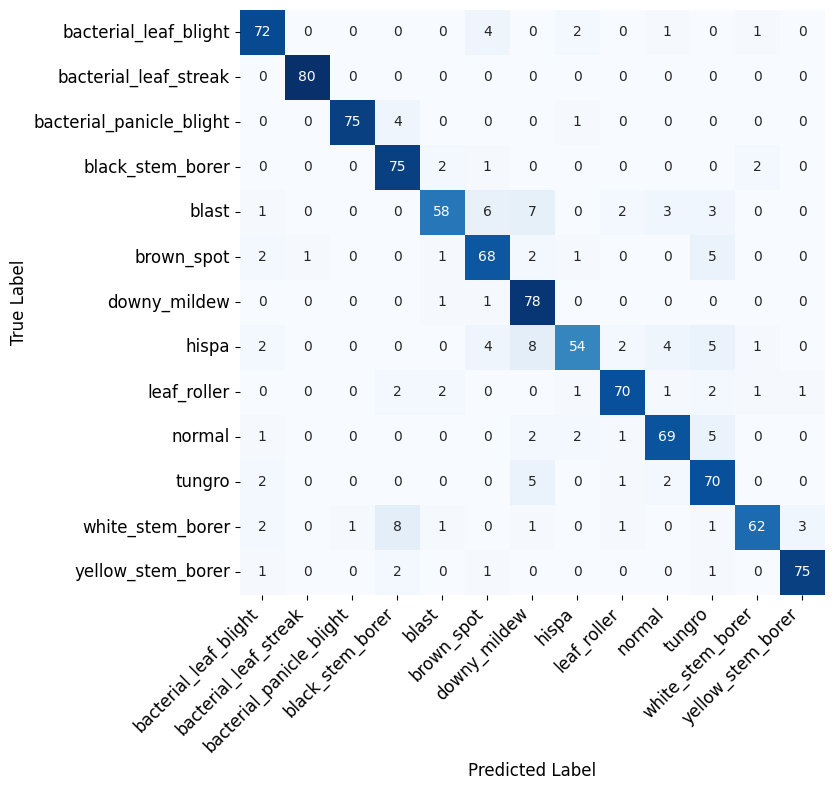

Confusion Matrix:
[[72  0  0  0  0  4  0  2  0  1  0  1  0]
 [ 0 80  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 75  4  0  0  0  1  0  0  0  0  0]
 [ 0  0  0 75  2  1  0  0  0  0  0  2  0]
 [ 1  0  0  0 58  6  7  0  2  3  3  0  0]
 [ 2  1  0  0  1 68  2  1  0  0  5  0  0]
 [ 0  0  0  0  1  1 78  0  0  0  0  0  0]
 [ 2  0  0  0  0  4  8 54  2  4  5  1  0]
 [ 0  0  0  2  2  0  0  1 70  1  2  1  1]
 [ 1  0  0  0  0  0  2  2  1 69  5  0  0]
 [ 2  0  0  0  0  0  5  0  1  2 70  0  0]
 [ 2  0  1  8  1  0  1  0  1  0  1 62  3]
 [ 1  0  0  2  0  1  0  0  0  0  1  0 75]]


In [16]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get the names of the classes
class_names = test_generator_vgg.class_indices.keys()

def plot_heatmap(y_true, y_pred, class_names, ax, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, 
        annot=True, 
        square=True, 
        xticklabels=class_names, 
        yticklabels=class_names,
        fmt='d', 
        cmap=plt.cm.Blues,
        cbar=False,
        ax=ax
    )
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, rotation=45, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_xlabel('Predicted Label', fontsize=12)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

plot_heatmap(true_classes, vgg_pred_classes_ft, class_names, ax, title="VGG16")    

plt.tight_layout()
plt.show()

# Print confusion matrix
cm = confusion_matrix(true_classes, vgg_pred_classes_ft)
print("Confusion Matrix:")
print(cm)

## Plot Training History

Let's visualize the training and validation metrics to understand model learning over time.

Keys in history: dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
Lengths of arrays:
accuracy: 53
loss: 53
val_accuracy: 27
val_loss: 27
Minimum length: 27


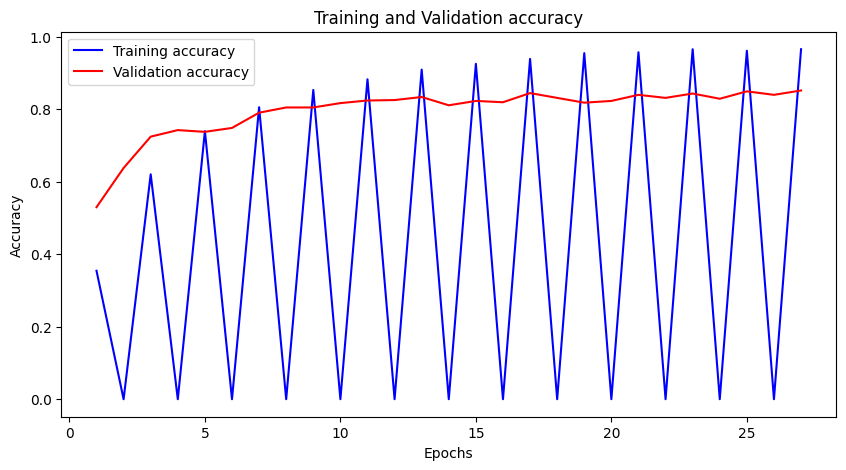

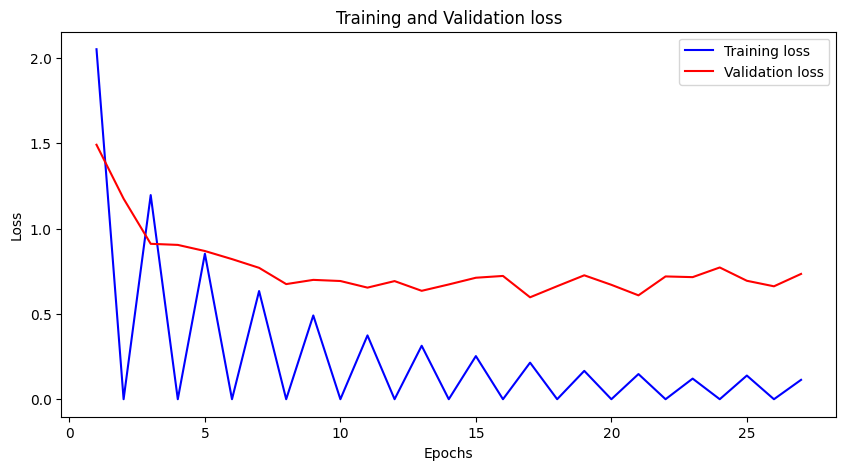

CPU times: user 324 ms, sys: 7.04 ms, total: 331 ms
Wall time: 326 ms


In [24]:
%%time
# Check the structure of history.history
print("Keys in history:", history.history.keys())
print("Lengths of arrays:")
for key in history.history:
    print(f"{key}: {len(history.history[key])}")

# Make sure all arrays are the same length
min_length = min(len(history.history[key]) for key in history.history)
print(f"Minimum length: {min_length}")

# Create a consistent history dictionary
consistent_history = {}
for key in history.history:
    consistent_history[key] = history.history[key][:min_length]

# Now create the DataFrame
temp = pd.DataFrame(consistent_history)
temp.to_csv('vgg_history.csv', index=False)

# Extract metrics for plotting
acc = consistent_history['accuracy']
val_acc = consistent_history['val_accuracy'] 
loss = consistent_history['loss']
val_loss = consistent_history['val_loss']
epochs = range(1, len(acc) + 1)

# Create figure 1: Accuracy
plt.figure(figsize=(10, 5))
plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Create figure 2: Loss
plt.figure(figsize=(10, 5))
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

## Run Final Test Predictions

We'll generate predictions on the full test set for submission.

In [25]:
STEP_SIZE_TEST=test_generator.n//test_generator.batch_size
test_generator.reset()
pred = vgg16_model.predict(
    test_generator,
    steps=STEP_SIZE_TEST,
    verbose=1
)

1040/1040 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step


## Generate Class Value Counts

Let's examine the distribution of predictions and ground truth classes.

In [26]:
# Display the distribution of training classes
print("Training Class Distribution:")
pd.Series(train_generator.classes).value_counts()

Training Class Distribution:


0     256
1     256
2     256
3     256
4     256
5     256
6     256
7     256
8     256
9     256
10    256
11    256
12    256
Name: count, dtype: int64

In [27]:
# Display the distribution of test classes
print("Test Class Distribution:")
pd.Series(test_generator.classes).value_counts()

Test Class Distribution:


0    1040
Name: count, dtype: int64

## Create Submission File

Generate a CSV submission file with image IDs and predicted labels.

In [28]:
predicted_class_indices=np.argmax(pred,axis=1)
labels = (train_generator.class_indices)

labels = dict((v,k) for k,v in labels.items())
predictions = [labels[k] for k in predicted_class_indices]

print("Prediction Distribution:")
pd.Series(predictions).value_counts()

Prediction Distribution:


downy_mildew                103
tungro                       92
black_stem_borer             91
brown_spot                   85
bacterial_leaf_blight        83
bacterial_leaf_streak        81
normal                       80
yellow_stem_borer            79
leaf_roller                  77
bacterial_panicle_blight     76
white_stem_borer             67
blast                        65
hispa                        61
Name: count, dtype: int64

In [29]:
filenames=test_generator.filenames

results=pd.DataFrame({
    "image_id": filenames,
    "label": predictions
})
results.image_id = results.image_id.str.replace('./', '')
results.to_csv("submission.csv",index=False)
print("Submission File Preview:")
results.head()

Submission File Preview:


,image_id,label
0,bacterial_leaf_blight/PDD00012.jpg,bacterial_leaf_blight
1,bacterial_leaf_blight/PDD00017.jpg,bacterial_leaf_blight
2,bacterial_leaf_blight/PDD00029.jpg,bacterial_leaf_blight
3,bacterial_leaf_blight/PDD00032.jpg,bacterial_leaf_blight
4,bacterial_leaf_blight/PDD00043.jpg,bacterial_leaf_blight


## Finish Weights & Biases Run

Close the Weights & Biases tracking session.

In [30]:
wandb.finish()